# Assignment 1
IN6227 Data Mining | Roshani Ayu Pranasti | G2504973A

## Import Libraries

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import time
import warnings
from sklearn.metrics import (
    accuracy_score, 
    auc,
    average_precision_score,
    classification_report, 
    confusion_matrix, 
    precision_recall_curve,
    roc_curve
)
from sklearn.model_selection import GridSearchCV
from sklearn.naive_bayes import GaussianNB, BernoulliNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import LabelEncoder

warnings.filterwarnings('ignore')

## Dataset Definition
Cencus Income Dataset splits into 2 types:
1. **Train Dataset**: `Census Income Data Set/adult.data`
2. **Test Dataset**: `Census Income Data Set/adult.test`

## Data Preparation

### Train Dataset

#### 1. Load Train Dataset

In [2]:
# Load dataset
cencus_income_train_dataset = pd.read_csv("Census Income Data Set/adult.data")
display(cencus_income_train_dataset)

,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
0,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
1,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
2,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
3,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K
4,37,Private,284582,Masters,14,Married-civ-spouse,Exec-managerial,Wife,White,Female,0,0,40,United-States,<=50K
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32555,27,Private,257302,Assoc-acdm,12,Married-civ-spouse,Tech-support,Wife,White,Female,0,0,38,United-States,<=50K
32556,40,Private,154374,HS-grad,9,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,0,0,40,United-States,>50K
32557,58,Private,151910,HS-grad,9,Widowed,Adm-clerical,Unmarried,White,Female,0,0,40,United-States,<=50K
32558,22,Private,201490,HS-grad,9,Never-married,Adm-clerical,Own-child,White,Male,0,0,20,United-States,<=50K


#### 2. Define Column Names
It can be seen that train dataset doesn't have a header row with column names, so I define them in a list based on column names defined in `adult.names`. This will make the data much easier to work with.

In [3]:
# Define the column names for the dataset
column_names = [
    "age", 
    "workclass", 
    "fnlwgt", 
    "education", 
    "education-num", 
    "marital-status", 
    "occupation", 
    "relationship", 
    "race", 
    "sex", 
    "capital-gain", 
    "capital-loss", 
    "hours-per-week",
    "native-country", 
    "income"
]

# Load dataset again with parameters:
# header=None: there's no header row in the file.
# names=column_names: assigns list of column names to the DataFrame.
# na_values="?": recognizes the string "?" as a missing or unknown value and represent it as NaN (Not a Number) in the DataFrame.
# skipinitialspace=True: saves from potential errors caused by inconsistent whitespace.
cencus_income_train_dataset = pd.read_csv("Census Income Data Set/adult.data", header=None, names=column_names, na_values="?", skipinitialspace=True)
cencus_income_train_dataset.head()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


#### 3. Explore Train Dataset

In [4]:
print("Number of attributes in dataset:", cencus_income_train_dataset.shape[1])
print("Number of data in dataset:", cencus_income_train_dataset.shape[0], "\n")
cencus_income_train_dataset.info()

Number of attributes in dataset: 15
Number of data in dataset: 32561 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             32561 non-null  int64 
 1   workclass       30725 non-null  object
 2   fnlwgt          32561 non-null  int64 
 3   education       32561 non-null  object
 4   education-num   32561 non-null  int64 
 5   marital-status  32561 non-null  object
 6   occupation      30718 non-null  object
 7   relationship    32561 non-null  object
 8   race            32561 non-null  object
 9   sex             32561 non-null  object
 10  capital-gain    32561 non-null  int64 
 11  capital-loss    32561 non-null  int64 
 12  hours-per-week  32561 non-null  int64 
 13  native-country  31978 non-null  object
 14  income          32561 non-null  object
dtypes: int64(6), object(9)
memory usage: 3.7+ MB


In [5]:
# Define numeric features
numerical_column_names = [
    "age",
    "fnlwgt",
    "education-num",
    "capital-gain",
    "capital-loss",
    "hours-per-week"
]

# Define categorical features
categorical_column_names = [
    "workclass",
    "education",
    "marital-status",
    "occupation",
    "relationship",
    "race",
    "sex",
    "native-country"
]

cencus_income_train_dataset[numerical_column_names].describe()

,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week
count,32561.000000,3.256100e+04,32561.000000,32561.000000,32561.000000,32561.000000
mean,38.581647,1.897784e+05,10.080679,1077.648844,87.303830,40.437456
std,13.640433,1.055500e+05,2.572720,7385.292085,402.960219,12.347429
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.178270e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.783560e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.370510e+05,12.000000,0.000000,0.000000,45.000000
max,90.000000,1.484705e+06,16.000000,99999.000000,4356.000000,99.000000


In [6]:
cencus_income_train_dataset[categorical_column_names].describe()

,workclass,education,marital-status,occupation,relationship,race,sex,native-country
count,30725,32561,32561,30718,32561,32561,32561,31978
unique,8,16,7,14,6,5,2,41
top,Private,HS-grad,Married-civ-spouse,Prof-specialty,Husband,White,Male,United-States
freq,22696,10501,14976,4140,13193,27816,21790,29170


#### 4. Check for Unknown or Missing Values  

In [7]:
print("Number of unknown or missing values in dataset:")
cencus_income_train_dataset.isnull().sum()

Number of unknown or missing values in dataset:


age                  0
workclass         1836
fnlwgt               0
education            0
education-num        0
marital-status       0
occupation        1843
relationship         0
race                 0
sex                  0
capital-gain         0
capital-loss         0
hours-per-week       0
native-country     583
income               0
dtype: int64

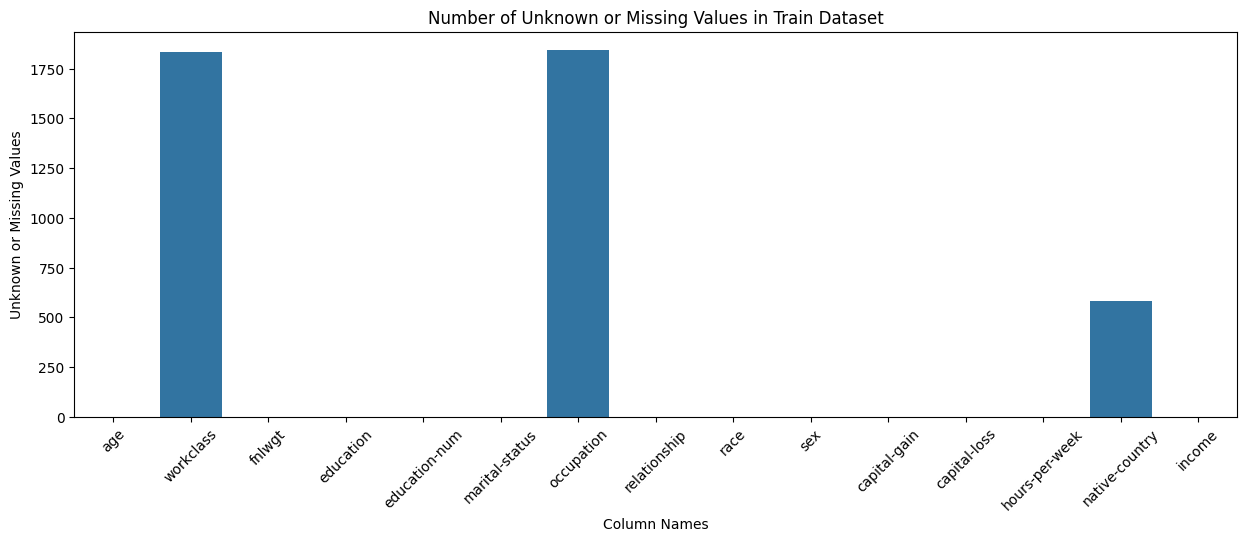

In [8]:
# Create the visualization of number of unknown or missing Values in dataset
plt.figure(figsize=(15, 5))
sns.barplot(x=cencus_income_train_dataset.isnull().sum().index, y=cencus_income_train_dataset.isnull().sum())
plt.title("Number of Unknown or Missing Values in Train Dataset")
plt.xlabel("Column Names")
plt.ylabel("Unknown or Missing Values")
plt.tick_params("x", rotation=45)

#### 5. Remove Unknown or Missing Values

In [9]:
# Remove rows with any missing values
cleaned_cencus_income_train_dataset = cencus_income_train_dataset.dropna()
cleaned_cencus_income_train_dataset.isnull().sum()

age               0
workclass         0
fnlwgt            0
education         0
education-num     0
marital-status    0
occupation        0
relationship      0
race              0
sex               0
capital-gain      0
capital-loss      0
hours-per-week    0
native-country    0
income            0
dtype: int64

#### 6. Remove Redundant or Noisy Columns
1. Drop `education` column since it is already covered by `education-num` in numerical type.
2. Drop `fnlwgt` column because, by the description, it is a statistical measure that is not useful for predicting an individual's income.


In [10]:
# Remove columns
cleaned_cencus_income_train_dataset.drop(["education", "fnlwgt"], axis=1, inplace=True)
display(cleaned_cencus_income_train_dataset)

,age,workclass,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K
...,...,...,...,...,...,...,...,...,...,...,...,...,...
32556,27,Private,12,Married-civ-spouse,Tech-support,Wife,White,Female,0,0,38,United-States,<=50K
32557,40,Private,9,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,0,0,40,United-States,>50K
32558,58,Private,9,Widowed,Adm-clerical,Unmarried,White,Female,0,0,40,United-States,<=50K
32559,22,Private,9,Never-married,Adm-clerical,Own-child,White,Male,0,0,20,United-States,<=50K


### Test Dataset

#### 1. Load Test Dataset

In [11]:
# Load dataset
cencus_income_test_dataset = pd.read_csv("Census Income Data Set/adult.test")
display(cencus_income_test_dataset)

,,,,,,,,,,,,,,|1x3 Cross validator
25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K.
38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K.
28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K.
44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K.
18,?,103497,Some-college,10,Never-married,?,Own-child,White,Female,0,0,30,United-States,<=50K.
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
39,Private,215419,Bachelors,13,Divorced,Prof-specialty,Not-in-family,White,Female,0,0,36,United-States,<=50K.
64,?,321403,HS-grad,9,Widowed,?,Other-relative,Black,Male,0,0,40,United-States,<=50K.
38,Private,374983,Bachelors,13,Married-civ-spouse,Prof-specialty,Husband,White,Male,0,0,50,United-States,<=50K.
44,Private,83891,Bachelors,13,Divorced,Adm-clerical,Own-child,Asian-Pac-Islander,Male,5455,0,40,United-States,<=50K.


#### 2. Define Column Names
It can be seen that test dataset has an irrelevant header row name, so I define them in a list based on column names defined in `adult.names`. This will make the data much easier to work with.

In [12]:
# Load dataset again with parameters:
# header=None: there's no header row in the file.
# names=column_names: assigns list of column names to the DataFrame.
# na_values="?": recognizes the string "?" as a missing or unknown value and represent it as NaN (Not a Number) in the DataFrame.
# skiprows=1: removes the first unwanted header.
# skipinitialspace=True: saves from potential errors caused by inconsistent whitespace.
cencus_income_test_dataset = pd.read_csv("Census Income Data Set/adult.test", header=None, names=column_names, na_values="?", skiprows=1, skipinitialspace=True)
cencus_income_test_dataset.head()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K.
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K.
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K.
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K.
4,18,NaN,103497,Some-college,10,Never-married,NaN,Own-child,White,Female,0,0,30,United-States,<=50K.


#### 3. Explore Train Dataset

In [13]:
print("Number of attributes in dataset:", cencus_income_test_dataset.shape[1])
print("Number of data in dataset:", cencus_income_test_dataset.shape[0], "\n")
cencus_income_test_dataset.info()

Number of attributes in dataset: 15
Number of data in dataset: 16281 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16281 entries, 0 to 16280
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             16281 non-null  int64 
 1   workclass       15318 non-null  object
 2   fnlwgt          16281 non-null  int64 
 3   education       16281 non-null  object
 4   education-num   16281 non-null  int64 
 5   marital-status  16281 non-null  object
 6   occupation      15315 non-null  object
 7   relationship    16281 non-null  object
 8   race            16281 non-null  object
 9   sex             16281 non-null  object
 10  capital-gain    16281 non-null  int64 
 11  capital-loss    16281 non-null  int64 
 12  hours-per-week  16281 non-null  int64 
 13  native-country  16007 non-null  object
 14  income          16281 non-null  object
dtypes: int64(6), object(9)
memory usage: 1.9+ MB


In [14]:
cencus_income_test_dataset[numerical_column_names].describe()

,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week
count,16281.000000,1.628100e+04,16281.000000,16281.000000,16281.000000,16281.000000
mean,38.767459,1.894357e+05,10.072907,1081.905104,87.899269,40.392236
std,13.849187,1.057149e+05,2.567545,7583.935968,403.105286,12.479332
min,17.000000,1.349200e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.167360e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.778310e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.383840e+05,12.000000,0.000000,0.000000,45.000000
max,90.000000,1.490400e+06,16.000000,99999.000000,3770.000000,99.000000


In [15]:
cencus_income_test_dataset[categorical_column_names].describe()

,workclass,education,marital-status,occupation,relationship,race,sex,native-country
count,15318,16281,16281,15315,16281,16281,16281,16007
unique,8,16,7,14,6,5,2,40
top,Private,HS-grad,Married-civ-spouse,Prof-specialty,Husband,White,Male,United-States
freq,11210,5283,7403,2032,6523,13946,10860,14662


#### 4. Check for Unknown or Missing Values  

In [16]:
print("Number of unknown or missing values in dataset:")
cencus_income_test_dataset.isnull().sum()

Number of unknown or missing values in dataset:


age                 0
workclass         963
fnlwgt              0
education           0
education-num       0
marital-status      0
occupation        966
relationship        0
race                0
sex                 0
capital-gain        0
capital-loss        0
hours-per-week      0
native-country    274
income              0
dtype: int64

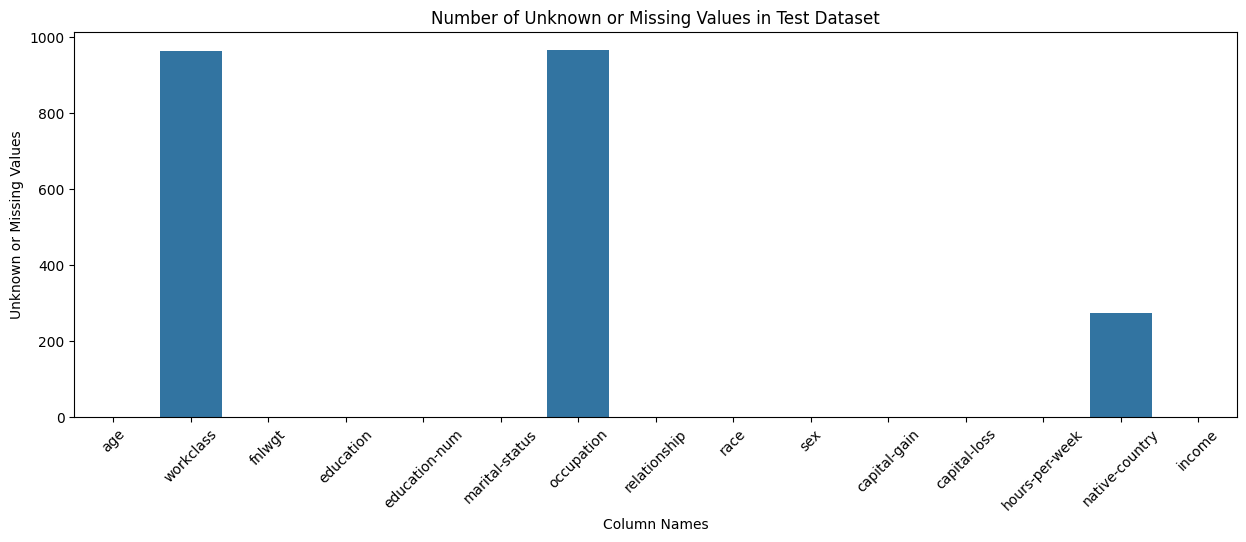

In [17]:
# Create the visualization of number of unknown or missing Values in dataset
plt.figure(figsize=(15, 5))
sns.barplot(x=cencus_income_test_dataset.isnull().sum().index, y=cencus_income_test_dataset.isnull().sum())
plt.title("Number of Unknown or Missing Values in Test Dataset")
plt.xlabel("Column Names")
plt.ylabel("Unknown or Missing Values")
plt.tick_params("x", rotation=45)

#### 5. Remove Unknown or Missing Values

In [18]:
# Remove rows with any missing values
cleaned_cencus_income_test_dataset = cencus_income_test_dataset.dropna()
cleaned_cencus_income_test_dataset.isnull().sum()

age               0
workclass         0
fnlwgt            0
education         0
education-num     0
marital-status    0
occupation        0
relationship      0
race              0
sex               0
capital-gain      0
capital-loss      0
hours-per-week    0
native-country    0
income            0
dtype: int64

#### 6. Remove Redundant or Noisy Columns
1. Drop `education` column since it is already covered by `education-num` in numerical type.
2. Drop `fnlwgt` column because, by the description, it is a statistical measure that is not useful for predicting an individual's income.

In [19]:
# Remove columns
cleaned_cencus_income_test_dataset.drop(["education", "fnlwgt"], axis=1, inplace=True)
display(cleaned_cencus_income_test_dataset)

,age,workclass,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,25,Private,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K.
1,38,Private,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K.
2,28,Local-gov,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K.
3,44,Private,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K.
5,34,Private,6,Never-married,Other-service,Not-in-family,White,Male,0,0,30,United-States,<=50K.
...,...,...,...,...,...,...,...,...,...,...,...,...,...
16275,33,Private,13,Never-married,Prof-specialty,Own-child,White,Male,0,0,40,United-States,<=50K.
16276,39,Private,13,Divorced,Prof-specialty,Not-in-family,White,Female,0,0,36,United-States,<=50K.
16278,38,Private,13,Married-civ-spouse,Prof-specialty,Husband,White,Male,0,0,50,United-States,<=50K.
16279,44,Private,13,Divorced,Adm-clerical,Own-child,Asian-Pac-Islander,Male,5455,0,40,United-States,<=50K.


#### 7. Adjust `income` Column Values
It can be seen that all the data in the `income` column consists of a period character or `"."`. I will remove it to make the data much easier to work with.

In [20]:
# Clean the income column in dataset
cleaned_cencus_income_test_dataset["income"] = cleaned_cencus_income_test_dataset["income"].str.replace(".", "", regex=False)
display(cleaned_cencus_income_test_dataset)

,age,workclass,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,25,Private,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K
3,44,Private,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K
5,34,Private,6,Never-married,Other-service,Not-in-family,White,Male,0,0,30,United-States,<=50K
...,...,...,...,...,...,...,...,...,...,...,...,...,...
16275,33,Private,13,Never-married,Prof-specialty,Own-child,White,Male,0,0,40,United-States,<=50K
16276,39,Private,13,Divorced,Prof-specialty,Not-in-family,White,Female,0,0,36,United-States,<=50K
16278,38,Private,13,Married-civ-spouse,Prof-specialty,Husband,White,Male,0,0,50,United-States,<=50K
16279,44,Private,13,Divorced,Adm-clerical,Own-child,Asian-Pac-Islander,Male,5455,0,40,United-States,<=50K


### Feature Engineering

Models often require numerical input. It is known that the train and test data have several categorical columns, like `workclass`, `occupation`, etc. I will convert these into a numerical format.

#### 1. One-Hot Encoding
Creates new binary (0 or 1) columns for each category within a feature to represent categorical data without implying an ordinal relationship.

In [21]:
# Separate features (X) and target (y)
X_train_data = cleaned_cencus_income_train_dataset.drop("income", axis=1)
y_train_data = cleaned_cencus_income_train_dataset["income"]
X_test_data = cleaned_cencus_income_test_dataset.drop("income", axis=1)
y_test_data = cleaned_cencus_income_test_dataset["income"]

# One-hot encode categorical features
X_train_data = pd.get_dummies(X_train_data, drop_first=True)
X_test_data = pd.get_dummies(X_test_data, drop_first=True)

print("Train data:")
display(X_train_data)
print("Test data:")
display(X_test_data)

Train data:


,age,education-num,capital-gain,capital-loss,hours-per-week,workclass_Local-gov,workclass_Private,workclass_Self-emp-inc,workclass_Self-emp-not-inc,workclass_State-gov,...,native-country_Portugal,native-country_Puerto-Rico,native-country_Scotland,native-country_South,native-country_Taiwan,native-country_Thailand,native-country_Trinadad&Tobago,native-country_United-States,native-country_Vietnam,native-country_Yugoslavia
0,39,13,2174,0,40,False,False,False,False,True,...,False,False,False,False,False,False,False,True,False,False
1,50,13,0,0,13,False,False,False,True,False,...,False,False,False,False,False,False,False,True,False,False
2,38,9,0,0,40,False,True,False,False,False,...,False,False,False,False,False,False,False,True,False,False
3,53,7,0,0,40,False,True,False,False,False,...,False,False,False,False,False,False,False,True,False,False
4,28,13,0,0,40,False,True,False,False,False,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32556,27,12,0,0,38,False,True,False,False,False,...,False,False,False,False,False,False,False,True,False,False
32557,40,9,0,0,40,False,True,False,False,False,...,False,False,False,False,False,False,False,True,False,False
32558,58,9,0,0,40,False,True,False,False,False,...,False,False,False,False,False,False,False,True,False,False
32559,22,9,0,0,20,False,True,False,False,False,...,False,False,False,False,False,False,False,True,False,False


Test data:


,age,education-num,capital-gain,capital-loss,hours-per-week,workclass_Local-gov,workclass_Private,workclass_Self-emp-inc,workclass_Self-emp-not-inc,workclass_State-gov,...,native-country_Portugal,native-country_Puerto-Rico,native-country_Scotland,native-country_South,native-country_Taiwan,native-country_Thailand,native-country_Trinadad&Tobago,native-country_United-States,native-country_Vietnam,native-country_Yugoslavia
0,25,7,0,0,40,False,True,False,False,False,...,False,False,False,False,False,False,False,True,False,False
1,38,9,0,0,50,False,True,False,False,False,...,False,False,False,False,False,False,False,True,False,False
2,28,12,0,0,40,True,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False
3,44,10,7688,0,40,False,True,False,False,False,...,False,False,False,False,False,False,False,True,False,False
5,34,6,0,0,30,False,True,False,False,False,...,False,False,False,False,False,False,False,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16275,33,13,0,0,40,False,True,False,False,False,...,False,False,False,False,False,False,False,True,False,False
16276,39,13,0,0,36,False,True,False,False,False,...,False,False,False,False,False,False,False,True,False,False
16278,38,13,0,0,50,False,True,False,False,False,...,False,False,False,False,False,False,False,True,False,False
16279,44,13,5455,0,40,False,True,False,False,False,...,False,False,False,False,False,False,False,True,False,False


#### 2. Column Alignment
After getting the result of one-hot encoding, it can be seen that the train and test data have a different number of columns.


In [22]:
print("Number of features in train data:", X_train_data.shape[1])
print("Number of features in test data:", X_test_data.shape[1])

Number of features in train data: 80
Number of features in test data: 79


This means the train data has a category that the test data doesn't. Hence, I align them to ensure they have the exact same columns.

In [23]:
# Align columns
train_columns = X_train_data.columns
test_columns = X_test_data.columns

missing_in_test = set(train_columns) - set(test_columns)
print("Columns that are missing in test data:", len(missing_in_test))
for column in missing_in_test:
    print("-", column)
    X_test_data[column] = 0

missing_in_train = set(test_columns) - set(train_columns)
print("\nColumns that are missing in train data:", len(missing_in_train))
for column in missing_in_train:
    print("-", column)
    X_train_data[column] = 0

# Ensure order is the same
X_test_data = X_test_data[train_columns] 

Columns that are missing in test data: 1
- native-country_Holand-Netherlands

Columns that are missing in train data: 0


In [24]:
print("Train data:")
display(X_train_data)
print("Test data:")
display(X_test_data)

Train data:


,age,education-num,capital-gain,capital-loss,hours-per-week,workclass_Local-gov,workclass_Private,workclass_Self-emp-inc,workclass_Self-emp-not-inc,workclass_State-gov,...,native-country_Portugal,native-country_Puerto-Rico,native-country_Scotland,native-country_South,native-country_Taiwan,native-country_Thailand,native-country_Trinadad&Tobago,native-country_United-States,native-country_Vietnam,native-country_Yugoslavia
0,39,13,2174,0,40,False,False,False,False,True,...,False,False,False,False,False,False,False,True,False,False
1,50,13,0,0,13,False,False,False,True,False,...,False,False,False,False,False,False,False,True,False,False
2,38,9,0,0,40,False,True,False,False,False,...,False,False,False,False,False,False,False,True,False,False
3,53,7,0,0,40,False,True,False,False,False,...,False,False,False,False,False,False,False,True,False,False
4,28,13,0,0,40,False,True,False,False,False,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32556,27,12,0,0,38,False,True,False,False,False,...,False,False,False,False,False,False,False,True,False,False
32557,40,9,0,0,40,False,True,False,False,False,...,False,False,False,False,False,False,False,True,False,False
32558,58,9,0,0,40,False,True,False,False,False,...,False,False,False,False,False,False,False,True,False,False
32559,22,9,0,0,20,False,True,False,False,False,...,False,False,False,False,False,False,False,True,False,False


Test data:


,age,education-num,capital-gain,capital-loss,hours-per-week,workclass_Local-gov,workclass_Private,workclass_Self-emp-inc,workclass_Self-emp-not-inc,workclass_State-gov,...,native-country_Portugal,native-country_Puerto-Rico,native-country_Scotland,native-country_South,native-country_Taiwan,native-country_Thailand,native-country_Trinadad&Tobago,native-country_United-States,native-country_Vietnam,native-country_Yugoslavia
0,25,7,0,0,40,False,True,False,False,False,...,False,False,False,False,False,False,False,True,False,False
1,38,9,0,0,50,False,True,False,False,False,...,False,False,False,False,False,False,False,True,False,False
2,28,12,0,0,40,True,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False
3,44,10,7688,0,40,False,True,False,False,False,...,False,False,False,False,False,False,False,True,False,False
5,34,6,0,0,30,False,True,False,False,False,...,False,False,False,False,False,False,False,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16275,33,13,0,0,40,False,True,False,False,False,...,False,False,False,False,False,False,False,True,False,False
16276,39,13,0,0,36,False,True,False,False,False,...,False,False,False,False,False,False,False,True,False,False
16278,38,13,0,0,50,False,True,False,False,False,...,False,False,False,False,False,False,False,True,False,False
16279,44,13,5455,0,40,False,True,False,False,False,...,False,False,False,False,False,False,False,True,False,False


#### 3. Label Encoding
The target variable `income` (<=50K and >50K) is also categorical. I will convert it into numerical labels (0 and 1).

In [25]:
print("Before label encoding:")
print("Train income target variable:\n", y_train_data)
print("Test income target variable:\n", y_test_data)

# Encode target variable
le = LabelEncoder()
y_train_data = le.fit_transform(y_train_data)
y_test_data = le.transform(y_test_data)

print("\nAfter label encoding:")
print("Train income target variable:", y_train_data)
print("Test income target variable:", y_test_data)

Before label encoding:
Train income target variable:
 0        <=50K
1        <=50K
2        <=50K
3        <=50K
4        <=50K
         ...  
32556    <=50K
32557     >50K
32558    <=50K
32559    <=50K
32560     >50K
Name: income, Length: 30162, dtype: object
Test income target variable:
 0        <=50K
1        <=50K
2         >50K
3         >50K
5        <=50K
         ...  
16275    <=50K
16276    <=50K
16278    <=50K
16279    <=50K
16280     >50K
Name: income, Length: 15060, dtype: object

After label encoding:
Train income target variable: [0 0 0 ... 0 0 1]
Test income target variable: [0 0 1 ... 0 0 1]


## Model Setup

### Naive Bayes Model

#### Gaussian Naive Bayes

In [26]:
# Initialize and train the model
print("Gaussian Naive Bayes Model")
gnb_model = GaussianNB()
start_gnb_train = time.time()
gnb_model.fit(X_train_data, y_train_data)
end_gnb_train = time.time()

gnb_train_time = end_gnb_train - start_gnb_train
print("Training Time:", gnb_train_time)

Gaussian Naive Bayes Model
Training Time: 0.017325162887573242


#### Bernoulli Naive Bayes

In [27]:
# Initialize and train the model
print("Bernoulli Naive Bayes Model")
bnb_model = BernoulliNB()
start_bnb_train = time.time()
bnb_model.fit(X_train_data, y_train_data)
end_bnb_train = time.time()

bnb_train_time = end_bnb_train - start_bnb_train
print("Training Time:", bnb_train_time)

Bernoulli Naive Bayes Model
Training Time: 0.01268911361694336


### k-Nearest Neighbors Model (k-NN) Model

In [28]:
# Initialize and train the model
print("k-NN Model (k=5)")
knn_model = KNeighborsClassifier(n_neighbors=5)
start_knn_train = time.time()
knn_model.fit(X_train_data, y_train_data)
end_knn_train = time.time()

knn_train_time = end_knn_train - start_knn_train
print("Training Time:", knn_train_time)

k-NN Model (k=5)
Training Time: 0.005348920822143555


### Hyperparameter Tuning

#### Naive Bayes Model
For Gaussian Naive Bayes, the main hyperparameter is `var_smoothing`. It's a stability parameter added to the variance calculation.

In [29]:
# Tune Naive Bayes
print("Tuning Naive Bayes Model")
param_grid_nb = {'var_smoothing': np.logspace(0,-9, num=100)}
grid_nb = GridSearchCV(GaussianNB(), param_grid_nb, cv=5, scoring='accuracy')
start_grid_nb_train = time.time()
grid_nb.fit(X_train_data, y_train_data)
end_grid_nb_train = time.time()

grid_nb_train_time = end_grid_nb_train - start_grid_nb_train
print("Best Naive Bayes Parameters:", grid_nb.best_params_)
print("Training Time:", grid_nb_train_time)

Tuning Naive Bayes Model
Best Naive Bayes Parameters: {'var_smoothing': np.float64(1.873817422860387e-09)}
Training Time: 8.583595037460327


#### k-Nearest Neighbors Model (k-NN) Model
For k-NN, the most critical hyperparameter is `n_neighbors` (the 'k'). I will search for the best 'k' from a list of odd numbers.

In [30]:
# Tune k-NN
print("Tuning k-NN Model")
param_grid_knn = {'n_neighbors': [3, 5, 7, 9, 11, 13, 15, 17, 19, 21]}
grid_knn = GridSearchCV(KNeighborsClassifier(), param_grid_knn, cv=5, scoring='accuracy')
start_grid_knn_train = time.time()
grid_knn.fit(X_train_data, y_train_data)
end_grid_knn_train = time.time()

grid_knn_train_time = end_grid_knn_train - start_grid_knn_train
print("Best k-NN Parameters:", grid_knn.best_params_)
print("Training Time:", grid_knn_train_time)

Tuning k-NN Model
Best k-NN Parameters: {'n_neighbors': 17}
Training Time: 61.72463893890381


## Model Evaluation

### Naive Bayes Model

#### Gaussian Naive Bayes

Gaussian Naive Bayes Model
Prediction Time: 0.0158078670501709
Accuracy: 0.8153386454183267

Classification Report:
               precision    recall  f1-score   support

       <=50K       0.91      0.84      0.87     11360
        >50K       0.60      0.75      0.67      3700

    accuracy                           0.82     15060
   macro avg       0.76      0.79      0.77     15060
weighted avg       0.84      0.82      0.82     15060


Confusion Matrix:
 [[9491 1869]
 [ 912 2788]]


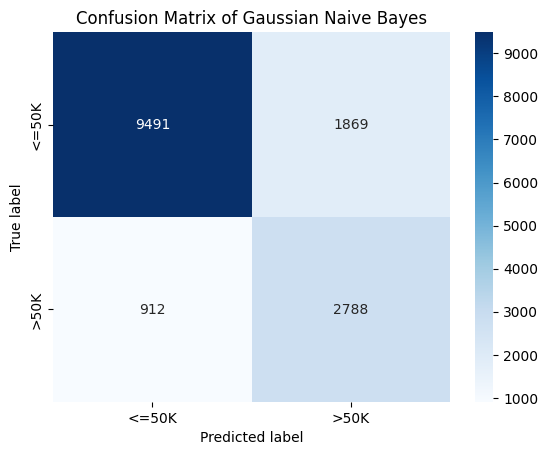

ROC Area Under the Curve (AUC): 0.8859526908070042
PR Average Precision (AP): 0.7228255411055774


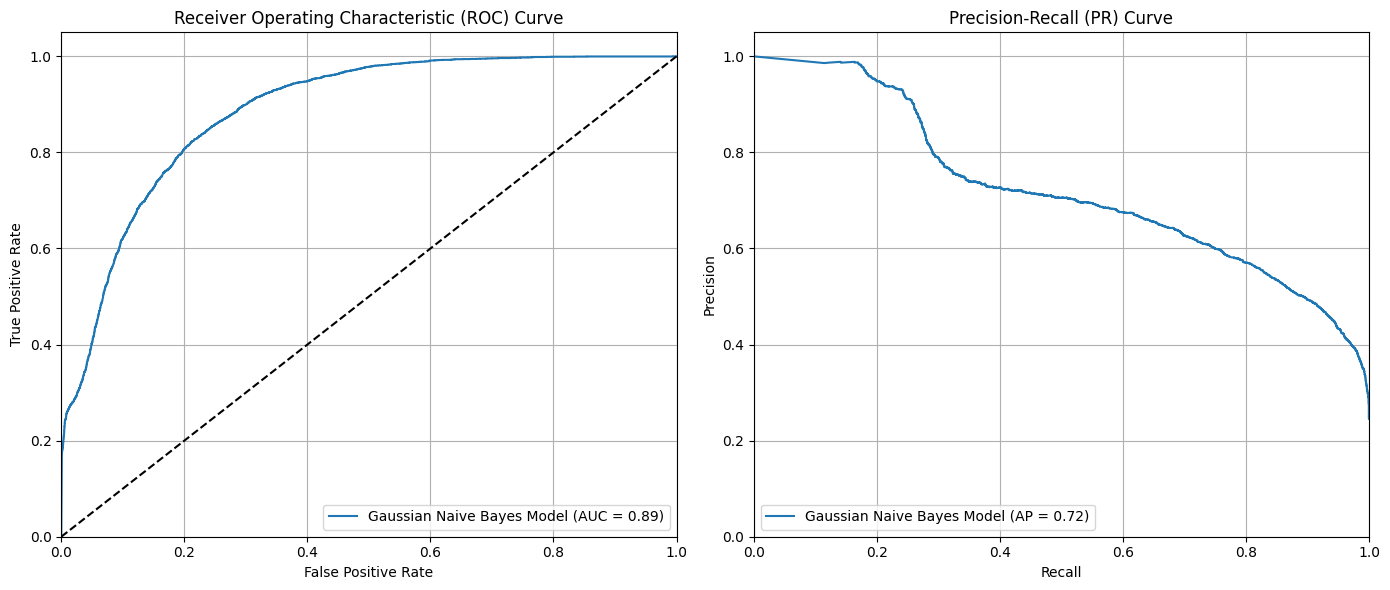

In [31]:
target_names = ["<=50K", ">50K"]

# Evaluate the model
start_gnb_pred = time.time()
gnb_predictions = gnb_model.predict(X_test_data)
gnb_probabilities = gnb_model.predict_proba(X_test_data)[:, 1]
end_gnb_pred = time.time()
gnb_pred_time = end_gnb_pred - start_gnb_pred

print("Gaussian Naive Bayes Model")
print("Prediction Time:", gnb_pred_time)
gnb_accuracy_score = accuracy_score(y_test_data, gnb_predictions)
print("Accuracy:", gnb_accuracy_score)
print("\nClassification Report:\n", classification_report(y_test_data, gnb_predictions, target_names=target_names))
gnb_report_dict = classification_report(y_test_data, gnb_predictions, target_names=target_names, output_dict=True)

# Confusion Matrix
gnb_confusion_matrix = confusion_matrix(y_test_data, gnb_predictions)
print("\nConfusion Matrix:\n", gnb_confusion_matrix)
plt.title("Confusion Matrix of Gaussian Naive Bayes")
sns.heatmap(gnb_confusion_matrix, annot=True, cmap=plt.cm.Blues, fmt="d", xticklabels=target_names, yticklabels=target_names)
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.show()

# Plot ROC and PR Curves
gnb_fpr, gnb_tpr, _ = roc_curve(y_test_data, gnb_probabilities)
gnb_roc_auc = auc(gnb_fpr, gnb_tpr)
print("ROC Area Under the Curve (AUC):", gnb_roc_auc)

gnb_precision, gnb_recall, _ = precision_recall_curve(y_test_data, gnb_probabilities)
gnb_avg_precision = average_precision_score(y_test_data, gnb_probabilities)
print("PR Average Precision (AP):", gnb_avg_precision)

plt.figure(figsize=(14, 6))

# ROC Curve plot
plt.subplot(1, 2, 1)
plt.plot(gnb_fpr, gnb_tpr, label=f"Gaussian Naive Bayes Model (AUC = {gnb_roc_auc:.2f})")
plt.plot([0, 1], [0, 1], 'k--') # Dashed diagonal line
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Receiver Operating Characteristic (ROC) Curve")
plt.legend(loc="lower right")
plt.grid(True)

# PR Curve plot
plt.subplot(1, 2, 2)
plt.plot(gnb_recall, gnb_precision, label=f"Gaussian Naive Bayes Model (AP = {gnb_avg_precision:.2f})")
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall (PR) Curve")
plt.legend(loc="lower left")
plt.grid(True)

plt.tight_layout()
plt.show()

#### Bernoulli Naive Bayes

Bernoulli Naive Bayes Model
Prediction Time: 0.013487100601196289
Accuracy: 0.7699203187250996

Classification Report:
               precision    recall  f1-score   support

       <=50K       0.92      0.76      0.83     11360
        >50K       0.52      0.79      0.63      3700

    accuracy                           0.77     15060
   macro avg       0.72      0.78      0.73     15060
weighted avg       0.82      0.77      0.78     15060


Confusion Matrix:
 [[8675 2685]
 [ 780 2920]]


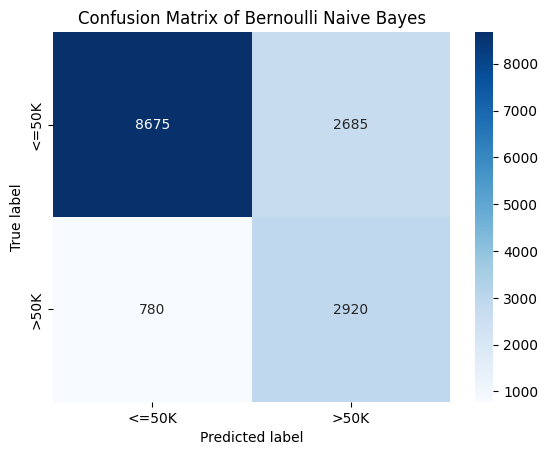

ROC Area Under the Curve (AUC): 0.8600117767415303
PR Average Precision (AP): 0.6475905619012372


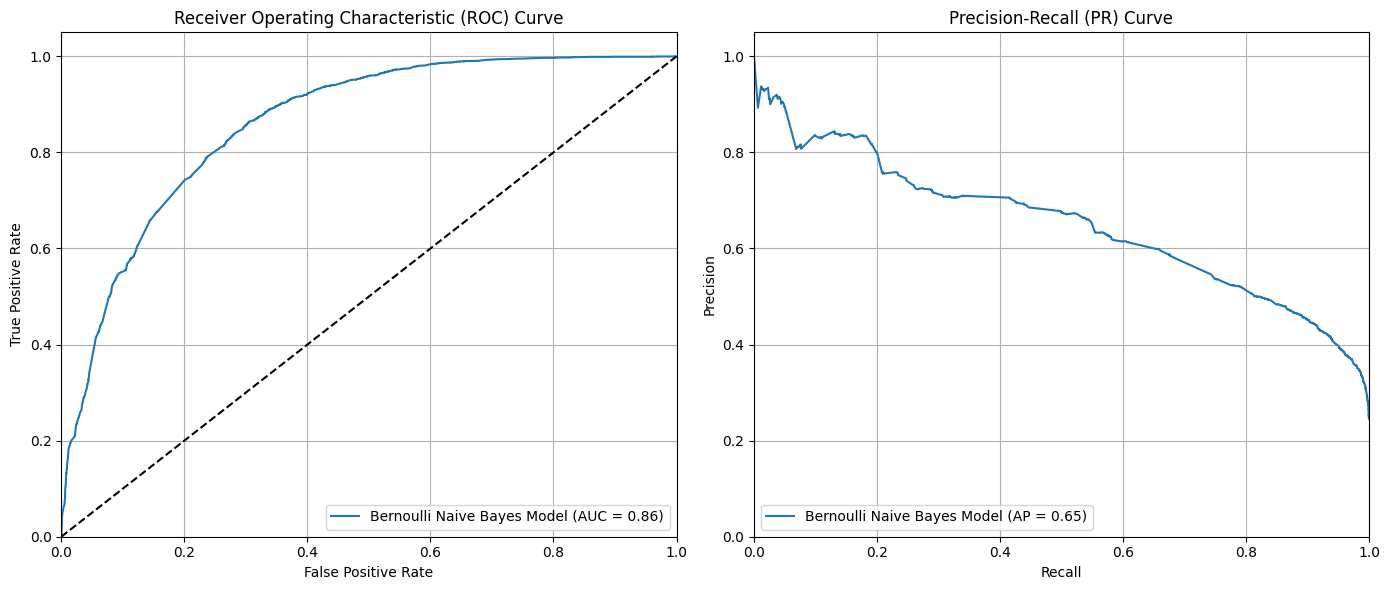

In [32]:
# Evaluate the model
start_bnb_pred = time.time()
bnb_predictions = bnb_model.predict(X_test_data)
bnb_probabilities = bnb_model.predict_proba(X_test_data)[:, 1]
end_bnb_pred = time.time()
bnb_pred_time = end_bnb_pred - start_bnb_pred

print("Bernoulli Naive Bayes Model")
print("Prediction Time:", bnb_pred_time)
bnb_accuracy_score = accuracy_score(y_test_data, bnb_predictions)
print("Accuracy:", bnb_accuracy_score)
print("\nClassification Report:\n", classification_report(y_test_data, bnb_predictions, target_names=target_names))
bnb_report_dict = classification_report(y_test_data, bnb_predictions, target_names=target_names, output_dict=True)

# Confusion Matrix
bnb_confusion_matrix = confusion_matrix(y_test_data, bnb_predictions)
print("\nConfusion Matrix:\n", bnb_confusion_matrix)
plt.title("Confusion Matrix of Bernoulli Naive Bayes")
sns.heatmap(bnb_confusion_matrix, annot=True, cmap=plt.cm.Blues, fmt="d", xticklabels=target_names, yticklabels=target_names)
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.show()

# Plot ROC and PR Curves
bnb_fpr, bnb_tpr, _ = roc_curve(y_test_data, bnb_probabilities)
bnb_roc_auc = auc(bnb_fpr, bnb_tpr)
print("ROC Area Under the Curve (AUC):", bnb_roc_auc)

bnb_precision, bnb_recall, _ = precision_recall_curve(y_test_data, bnb_probabilities)
bnb_avg_precision = average_precision_score(y_test_data, bnb_probabilities)
print("PR Average Precision (AP):", bnb_avg_precision)

plt.figure(figsize=(14, 6))

# ROC Curve plot
plt.subplot(1, 2, 1)
plt.plot(bnb_fpr, bnb_tpr, label=f"Bernoulli Naive Bayes Model (AUC = {bnb_roc_auc:.2f})")
plt.plot([0, 1], [0, 1], 'k--') # Dashed diagonal line
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Receiver Operating Characteristic (ROC) Curve")
plt.legend(loc="lower right")
plt.grid(True)

# PR Curve plot
plt.subplot(1, 2, 2)
plt.plot(bnb_recall, bnb_precision, label=f"Bernoulli Naive Bayes Model (AP = {bnb_avg_precision:.2f})")
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall (PR) Curve")
plt.legend(loc="lower left")
plt.grid(True)

plt.tight_layout()
plt.show()

### Best Naive Bayes Model


Best Naive Bayes Model Evaluation
Prediction Time: 0.010918140411376953
Accuracy: 0.8276892430278885

Classification Report:
               precision    recall  f1-score   support

       <=50K       0.88      0.89      0.89     11360
        >50K       0.66      0.63      0.64      3700

    accuracy                           0.83     15060
   macro avg       0.77      0.76      0.76     15060
weighted avg       0.83      0.83      0.83     15060


Confusion Matrix:
 [[10141  1219]
 [ 1376  2324]]


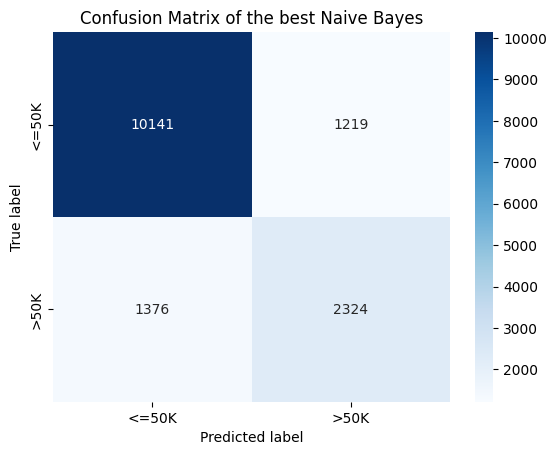

ROC Area Under the Curve (AUC): 0.8843051960411116
PR Average Precision (AP): 0.7137838624716125


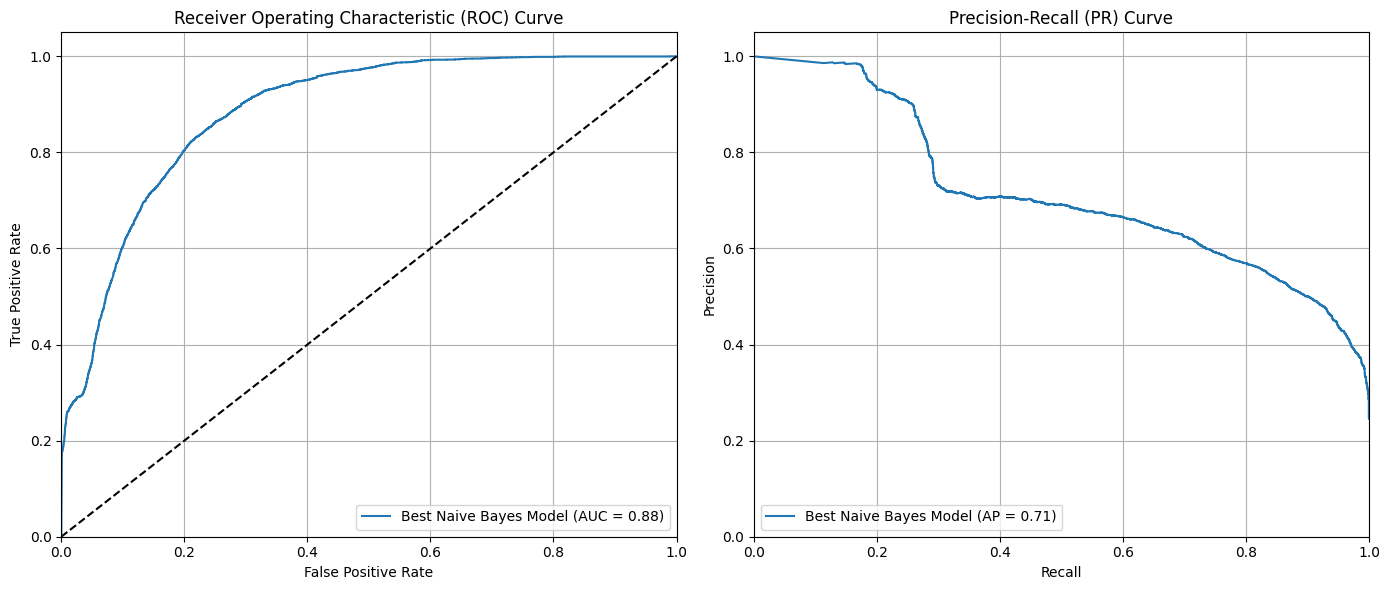

In [33]:
# Evaluate the best Naive Bayes model
best_nb = grid_nb.best_estimator_
start_best_nb_pred = time.time()
best_nb_predictions = best_nb.predict(X_test_data)
best_nb_probabilities = best_nb.predict_proba(X_test_data)[:, 1]
end_best_nb_pred = time.time()
best_nb_pred_time = end_best_nb_pred - start_best_nb_pred

print("\nBest Naive Bayes Model Evaluation")
print("Prediction Time:", best_nb_pred_time)
best_nb_accuracy_score = accuracy_score(y_test_data, best_nb_predictions)
print("Accuracy:", best_nb_accuracy_score)
print("\nClassification Report:\n", classification_report(y_test_data, best_nb_predictions, target_names=target_names))
best_nb_report_dict = classification_report(y_test_data, best_nb_predictions, target_names=target_names, output_dict=True)

# Confusion Matrix
best_nb_confusion_matrix = confusion_matrix(y_test_data, best_nb_predictions)
print("\nConfusion Matrix:\n", best_nb_confusion_matrix)
plt.title("Confusion Matrix of the best Naive Bayes")
sns.heatmap(best_nb_confusion_matrix, annot=True, cmap=plt.cm.Blues, fmt="d", xticklabels=target_names, yticklabels=target_names)
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.show()

# Plot ROC and PR Curves
best_nb_fpr, best_nb_tpr, _ = roc_curve(y_test_data, best_nb_probabilities)
best_nb_roc_auc = auc(best_nb_fpr, best_nb_tpr)
print("ROC Area Under the Curve (AUC):", best_nb_roc_auc)

best_nb_precision, best_nb_recall, _ = precision_recall_curve(y_test_data, best_nb_probabilities)
best_nb_avg_precision = average_precision_score(y_test_data, best_nb_probabilities)
print("PR Average Precision (AP):", best_nb_avg_precision)

plt.figure(figsize=(14, 6))

# ROC Curve plot
plt.subplot(1, 2, 1)
plt.plot(best_nb_fpr, best_nb_tpr, label=f"Best Naive Bayes Model (AUC = {best_nb_roc_auc:.2f})")
plt.plot([0, 1], [0, 1], 'k--') # Dashed diagonal line
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Receiver Operating Characteristic (ROC) Curve")
plt.legend(loc="lower right")
plt.grid(True)

# PR Curve plot
plt.subplot(1, 2, 2)
plt.plot(best_nb_recall, best_nb_precision, label=f"Best Naive Bayes Model (AP = {best_nb_avg_precision:.2f})")
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall (PR) Curve")
plt.legend(loc="lower left")
plt.grid(True)

plt.tight_layout()
plt.show()

### k-NN Model (k=5)

k-NN Model (k=5)
Prediction Time: 7.974090099334717
Accuracy: 0.8388446215139442

Classification Report:
               precision    recall  f1-score   support

       <=50K       0.89      0.90      0.89     11360
        >50K       0.68      0.65      0.67      3700

    accuracy                           0.84     15060
   macro avg       0.78      0.78      0.78     15060
weighted avg       0.84      0.84      0.84     15060


Confusion Matrix:
 [[10211  1149]
 [ 1278  2422]]


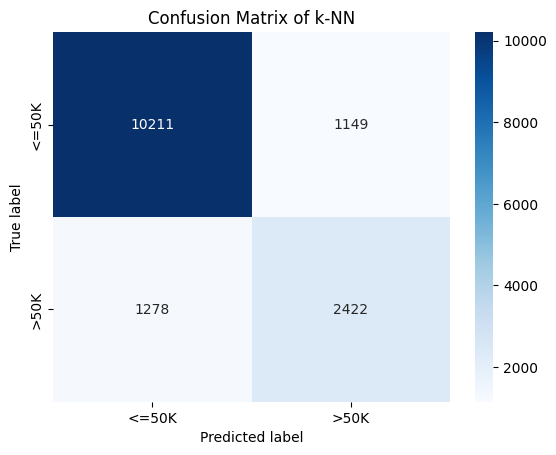

ROC Area Under the Curve (AUC): 0.8760831271412257
PR Average Precision (AP): 0.7038519737807932


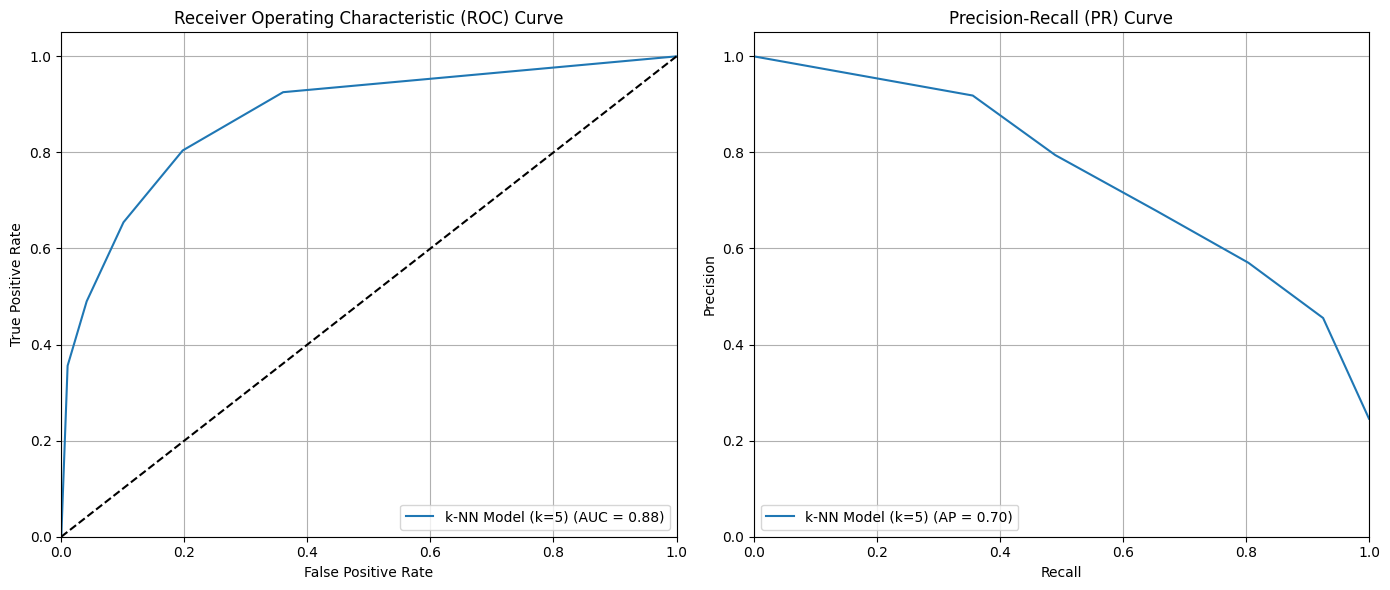

In [34]:
# Evaluate the model
start_knn_pred = time.time()
knn_predictions = knn_model.predict(X_test_data)
knn_probabilities = knn_model.predict_proba(X_test_data)[:, 1]
end_knn_pred = time.time()
knn_pred_time = end_knn_pred - start_knn_pred

print("k-NN Model (k=5)")
print("Prediction Time:", knn_pred_time)
knn_accuracy_score = accuracy_score(y_test_data, knn_predictions)
print("Accuracy:", knn_accuracy_score)
print("\nClassification Report:\n", classification_report(y_test_data, knn_predictions, target_names=target_names))
knn_report_dict = classification_report(y_test_data, knn_predictions, target_names=target_names, output_dict=True)

# Confusion Matrix
knn_confusion_matrix = confusion_matrix(y_test_data, knn_predictions)
print("\nConfusion Matrix:\n", knn_confusion_matrix)
plt.title("Confusion Matrix of k-NN")
sns.heatmap(knn_confusion_matrix, annot=True, cmap=plt.cm.Blues, fmt="d", xticklabels=target_names, yticklabels=target_names)
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.show()

# Plot ROC and PR Curves
knn_fpr, knn_tpr, _ = roc_curve(y_test_data, knn_probabilities)
knn_roc_auc = auc(knn_fpr, knn_tpr)
print("ROC Area Under the Curve (AUC):", knn_roc_auc)

knn_precision, knn_recall, _ = precision_recall_curve(y_test_data, knn_probabilities)
knn_avg_precision = average_precision_score(y_test_data, knn_probabilities)
print("PR Average Precision (AP):", knn_avg_precision)

plt.figure(figsize=(14, 6))

# ROC Curve plot
plt.subplot(1, 2, 1)
plt.plot(knn_fpr, knn_tpr, label=f"k-NN Model (k=5) (AUC = {knn_roc_auc:.2f})")
plt.plot([0, 1], [0, 1], 'k--') # Dashed diagonal line
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Receiver Operating Characteristic (ROC) Curve")
plt.legend(loc="lower right")
plt.grid(True)

# PR Curve plot
plt.subplot(1, 2, 2)
plt.plot(knn_recall, knn_precision, label=f"k-NN Model (k=5) (AP = {knn_avg_precision:.2f})")
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall (PR) Curve")
plt.legend(loc="lower left")
plt.grid(True)

plt.tight_layout()
plt.show()

### Best k-NN Model (k=17)


Best k-NN Model (k=17) Evaluation
Prediction Time: 7.8658270835876465
Accuracy: 0.8474103585657371

Classification Report:
               precision    recall  f1-score   support

       <=50K       0.88      0.92      0.90     11360
        >50K       0.72      0.63      0.67      3700

    accuracy                           0.85     15060
   macro avg       0.80      0.77      0.78     15060
weighted avg       0.84      0.85      0.84     15060


Confusion Matrix:
 [[10441   919]
 [ 1379  2321]]


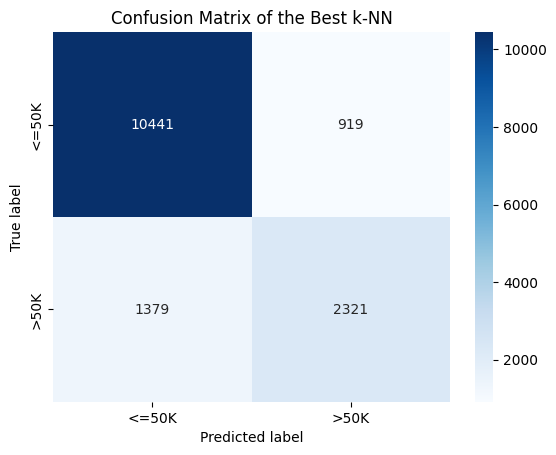

ROC Area Under the Curve (AUC): 0.8988314855348306
PR Average Precision (AP): 0.7674776850871895


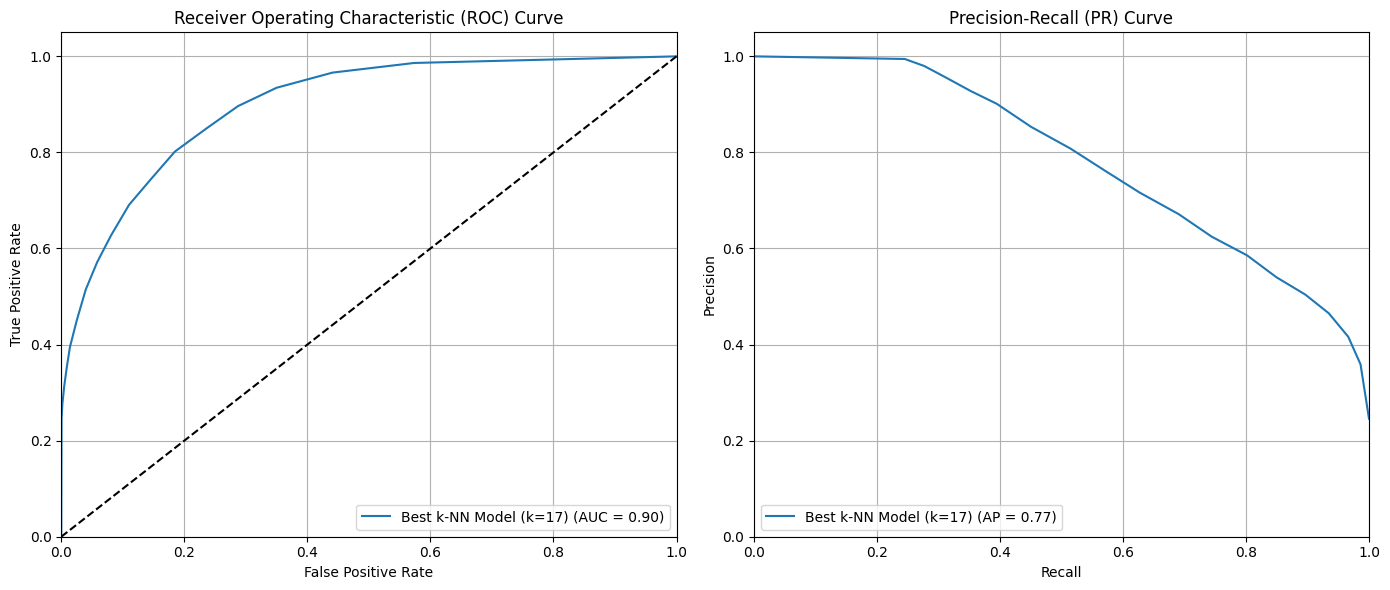

In [35]:
# Evaluate the best k-NN model
best_knn = grid_knn.best_estimator_
start_best_knn_pred = time.time()
best_knn_predictions = best_knn.predict(X_test_data)
best_knn_probabilities = best_knn.predict_proba(X_test_data)[:, 1]
end_best_knn_pred = time.time()
best_knn_pred_time = end_best_knn_pred - start_best_knn_pred

print("\nBest k-NN Model (k=17) Evaluation")
print("Prediction Time:", best_knn_pred_time)
best_knn_accuracy_score = accuracy_score(y_test_data, best_knn_predictions)
print("Accuracy:", best_knn_accuracy_score)
print("\nClassification Report:\n", classification_report(y_test_data, best_knn_predictions, target_names=target_names))
best_knn_report_dict = classification_report(y_test_data, best_knn_predictions, target_names=target_names, output_dict=True)

# Confusion Matrix
best_knn_confusion_matrix = confusion_matrix(y_test_data, best_knn_predictions)
print("\nConfusion Matrix:\n", best_knn_confusion_matrix)
plt.title("Confusion Matrix of the Best k-NN")
sns.heatmap(best_knn_confusion_matrix, annot=True, cmap=plt.cm.Blues, fmt="d", xticklabels=target_names, yticklabels=target_names)
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.show()

# Plot ROC and PR Curves
best_knn_fpr, best_knn_tpr, _ = roc_curve(y_test_data, best_knn_probabilities)
best_knn_roc_auc = auc(best_knn_fpr, best_knn_tpr)
print("ROC Area Under the Curve (AUC):", best_knn_roc_auc)

best_knn_precision, best_knn_recall, _ = precision_recall_curve(y_test_data, best_knn_probabilities)
best_knn_avg_precision = average_precision_score(y_test_data, best_knn_probabilities)
print("PR Average Precision (AP):", best_knn_avg_precision)

plt.figure(figsize=(14, 6))

# ROC Curve plot
plt.subplot(1, 2, 1)
plt.plot(best_knn_fpr, best_knn_tpr, label=f"Best k-NN Model (k=17) (AUC = {best_knn_roc_auc:.2f})")
plt.plot([0, 1], [0, 1], 'k--') # Dashed diagonal line
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Receiver Operating Characteristic (ROC) Curve")
plt.legend(loc="lower right")
plt.grid(True)

# PR Curve plot
plt.subplot(1, 2, 2)
plt.plot(best_knn_recall, best_knn_precision, label=f"Best k-NN Model (k=17) (AP = {best_knn_avg_precision:.2f})")
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall (PR) Curve")
plt.legend(loc="lower left")
plt.grid(True)

plt.tight_layout()
plt.show()

## Comparison

In [36]:
print("Models Comparison by Metrics")
print("\nAccuracy:")

print("1. Gaussian Naive Bayes: %s%%" % (100*gnb_accuracy_score))
print("2. Bernoulli Naive Bayes: %s%%" % (100*bnb_accuracy_score))
print("3. Tuned Naive Bayes: %s%%" % (100*best_nb_accuracy_score))
print("4. k-NN (k=5): %s%%" % (100*knn_accuracy_score))
print("5. Tuned k-NN (k=17): %s%%" % (100*best_knn_accuracy_score))

print("\nPrecision (>50K):")
print("1. Gaussian Naive Bayes:", gnb_report_dict['>50K']['precision'])
print("2. Bernoulli Naive Bayes:", bnb_report_dict['>50K']['precision'])
print("3. Tuned Naive Bayes:", best_nb_report_dict['>50K']['precision'])
print("4. k-NN (k=5):", knn_report_dict['>50K']['precision'])
print("5. Tuned k-NN (k=17):", best_knn_report_dict['>50K']['precision'])

print("\nRecall (>50K):")
print("1. Gaussian Naive Bayes:", gnb_report_dict['>50K']['recall'])
print("2. Bernoulli Naive Bayes:", bnb_report_dict['>50K']['recall'])
print("3. Tuned Naive Bayes:", best_nb_report_dict['>50K']['recall'])
print("4. k-NN (k=5):", knn_report_dict['>50K']['recall'])
print("5. Tuned k-NN (k=17):", best_knn_report_dict['>50K']['recall'])

print("\nF1-Score (>50K):")
print("1. Gaussian Naive Bayes:", gnb_report_dict['>50K']['f1-score'])
print("2. Bernoulli Naive Bayes:", bnb_report_dict['>50K']['f1-score'])
print("3. Tuned Naive Bayes:", best_nb_report_dict['>50K']['f1-score'])
print("4. k-NN (k=5):", knn_report_dict['>50K']['f1-score'])
print("5. Tuned k-NN (k=17):", best_knn_report_dict['>50K']['f1-score'])

Models Comparison by Metrics

Accuracy:
1. Gaussian Naive Bayes: 81.53386454183267%
2. Bernoulli Naive Bayes: 76.99203187250995%
3. Tuned Naive Bayes: 82.76892430278885%
4. k-NN (k=5): 83.88446215139442%
5. Tuned k-NN (k=17): 84.74103585657372%

Precision (>50K):
1. Gaussian Naive Bayes: 0.5986686708181232
2. Bernoulli Naive Bayes: 0.5209634255129348
3. Tuned Naive Bayes: 0.6559412926898109
4. k-NN (k=5): 0.678241388966676
5. Tuned k-NN (k=17): 0.716358024691358

Recall (>50K):
1. Gaussian Naive Bayes: 0.7535135135135135
2. Bernoulli Naive Bayes: 0.7891891891891892
3. Tuned Naive Bayes: 0.6281081081081081
4. k-NN (k=5): 0.6545945945945946
5. Tuned k-NN (k=17): 0.6272972972972973

F1-Score (>50K):
1. Gaussian Naive Bayes: 0.6672250807706115
2. Bernoulli Naive Bayes: 0.6276195593766792
3. Tuned Naive Bayes: 0.6417230429380091
4. k-NN (k=5): 0.6662082244533076
5. Tuned k-NN (k=17): 0.6688760806916426


In [37]:
print("\nTraining Time:")
print("1. Gaussian Naive Bayes:", gnb_train_time)
print("2. Bernoulli Naive Bayes:", bnb_train_time)
print("3. Tuned Naive Bayes:", grid_nb_train_time)
print("4. k-NN (k=5):", knn_train_time)
print("5. Tuned k-NN (k=17):", grid_knn_train_time)

print("\nPrediction Time:")
print("1. Gaussian Naive Bayes:", gnb_pred_time)
print("2. Bernoulli Naive Bayes:", bnb_pred_time)
print("3. Tuned Naive Bayes:", best_nb_pred_time)
print("4. k-NN (k=5):", knn_pred_time)
print("5. Tuned k-NN (k=17):", best_knn_pred_time)


Training Time:
1. Gaussian Naive Bayes: 0.017325162887573242
2. Bernoulli Naive Bayes: 0.01268911361694336
3. Tuned Naive Bayes: 8.583595037460327
4. k-NN (k=5): 0.005348920822143555
5. Tuned k-NN (k=17): 61.72463893890381

Prediction Time:
1. Gaussian Naive Bayes: 0.0158078670501709
2. Bernoulli Naive Bayes: 0.013487100601196289
3. Tuned Naive Bayes: 0.010918140411376953
4. k-NN (k=5): 7.974090099334717
5. Tuned k-NN (k=17): 7.8658270835876465


ROC Area Under the Curve (AUC):


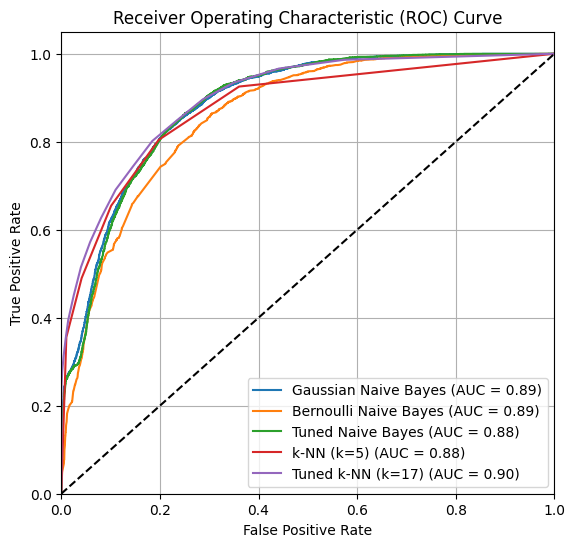

In [38]:
print("ROC Area Under the Curve (AUC):")
plt.figure(figsize=(14, 6))
plt.subplot(1, 2, 1)
plt.plot(gnb_fpr, gnb_tpr, label=f"Gaussian Naive Bayes (AUC = {gnb_roc_auc:.2f})")
plt.plot(bnb_fpr, bnb_tpr, label=f"Bernoulli Naive Bayes (AUC = {gnb_roc_auc:.2f})")
plt.plot(best_nb_fpr, best_nb_tpr, label=f"Tuned Naive Bayes (AUC = {best_nb_roc_auc:.2f})")
plt.plot(knn_fpr, knn_tpr, label=f"k-NN (k=5) (AUC = {knn_roc_auc:.2f})")
plt.plot(best_knn_fpr, best_knn_tpr, label=f"Tuned k-NN (k=17) (AUC = {best_knn_roc_auc:.2f})")
plt.plot([0, 1], [0, 1], 'k--') # Dashed diagonal line
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Receiver Operating Characteristic (ROC) Curve")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

PR Average Precision (AP):


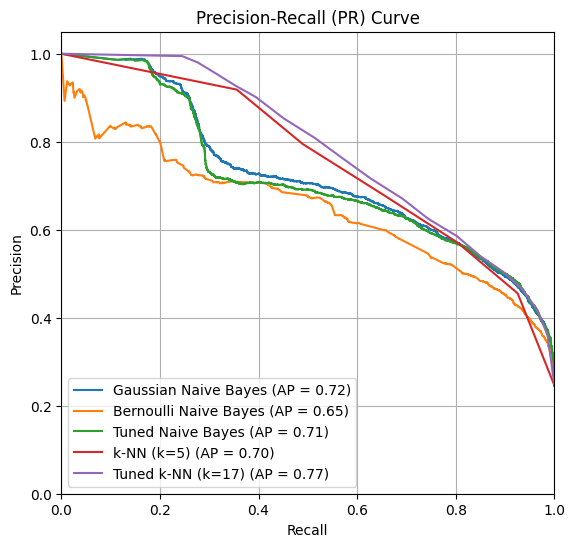

In [39]:
print("PR Average Precision (AP):")
plt.figure(figsize=(14, 6))
plt.subplot(1, 2, 2)
plt.plot(gnb_recall, gnb_precision, label=f"Gaussian Naive Bayes (AP = {gnb_avg_precision:.2f})")
plt.plot(bnb_recall, bnb_precision, label=f"Bernoulli Naive Bayes (AP = {bnb_avg_precision:.2f})")
plt.plot(best_nb_recall, best_nb_precision, label=f"Tuned Naive Bayes (AP = {best_nb_avg_precision:.2f})")
plt.plot(knn_recall, knn_precision, label=f"k-NN (k=5) (AP = {knn_avg_precision:.2f})")
plt.plot(best_knn_recall, best_knn_precision, label=f"Tuned k-NN (k=17) (AP = {best_knn_avg_precision:.2f})")
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall (PR) Curve")
plt.legend(loc="lower left")
plt.grid(True)
plt.show()